We first recreate what already done in the main [Demos](https://pennylane.ai/qml/demos/tutorial_annni#unsupervised-learning-of-phases-quantum-anomaly-detection) but using our [VQE](https://github.com/alexsockz/ANNNI-model-quantum-computing/blob/main/src/VQE.py)

In [1]:
import pennylane as qml
import numpy as np
from jax import jit, vmap, value_and_grad, random, config
from jax import numpy as jnp
import optax

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import tqdm 
import pantarei


config.update("jax_enable_x64", True)

seed = 123456

# Setting our constants
num_qubits = 8 # Number of spins in the Hamiltonian (= number of qubits)
side = 40      # Discretization of the Phase Diagram


In [2]:
def get_H(num_spins, k, h):
    """Construction function the ANNNI Hamiltonian (J=1)"""

    # Interaction between spins (neighbouring):
    H = -1 * (qml.PauliX(0) @ qml.PauliX(1))
    for i in range(1, num_spins - 1):
        H = H  - (qml.PauliX(i) @ qml.PauliX(i + 1))

    # Interaction between spins (next-neighbouring):
    for i in range(0, num_spins - 2):
        H = H + k * (qml.PauliX(i) @ qml.PauliX(i + 2))

    # Interaction of the spins with the magnetic field
    for i in range(0, num_spins):
        H = H - h * qml.PauliZ(i)

    return H


In [3]:
def kt_transition(k):
    """Kosterlitz-Thouless transition line"""
    return 1.05 * np.sqrt((k - 0.5) * (k - 0.1))

def ising_transition(k):
    """Ising transition line"""
    return np.where(k == 0, 1, (1 - k) * (1 - np.sqrt((1 - 3 * k + 4 * k**2) / (1 - k))) / np.maximum(k, 1e-9))

def bkt_transition(k):
    """Floating Phase transition line"""
    return 1.05 * (k - 0.5)

def get_phase(k, h):
    """Get the phase from the DMRG transition lines"""
    # If under the Ising Transition Line (Left side)
    if k < .5 and h < ising_transition(k):
        return 0 # Ferromagnetic
    # If under the Kosterlitz-Thouless Transition Line (Right side)

    elif k > .5 and h < kt_transition(k):
        return 1 # Antiphase
    return 2 # else it is Paramagnetic


In [4]:
def diagonalize_H(H_matrix):
    """Returns the lowest eigenvector of the Hamiltonian matrix."""
    _, psi = jnp.linalg.eigh(H_matrix)  # Compute eigenvalues and eigenvectors
    return jnp.array(psi[:, 0], dtype=jnp.complex64)  # Return the ground state

# Create meshgrid of the parameter space
ks = np.linspace(0, 1, side)
hs = np.linspace(0, 2, side)
K, H = np.meshgrid(ks, hs)

# Preallocate arrays for Hamiltonian matrices and phase labels.
H_matrices = np.empty((len(ks), len(hs), 2**num_qubits, 2**num_qubits))
phases = np.empty((len(ks), len(hs)), dtype=int)

for x, k in enumerate(ks):
    for y, h in enumerate(hs):
        H_matrices[y, x] = np.real(qml.matrix(get_H(num_qubits, k, h))) # Get Hamiltonian matrix
        phases[y, x] = get_phase(k, h)  # Get the respective phase given k and h

# Vectorized diagonalization
psis = vmap(vmap(diagonalize_H))(H_matrices)


Let's import our VQE:

In [8]:
from VQE import VQE
# vqe = VQE(n_wires=num_qubits, n_layers=9, k=k, h=h, shots=None, noise=False)

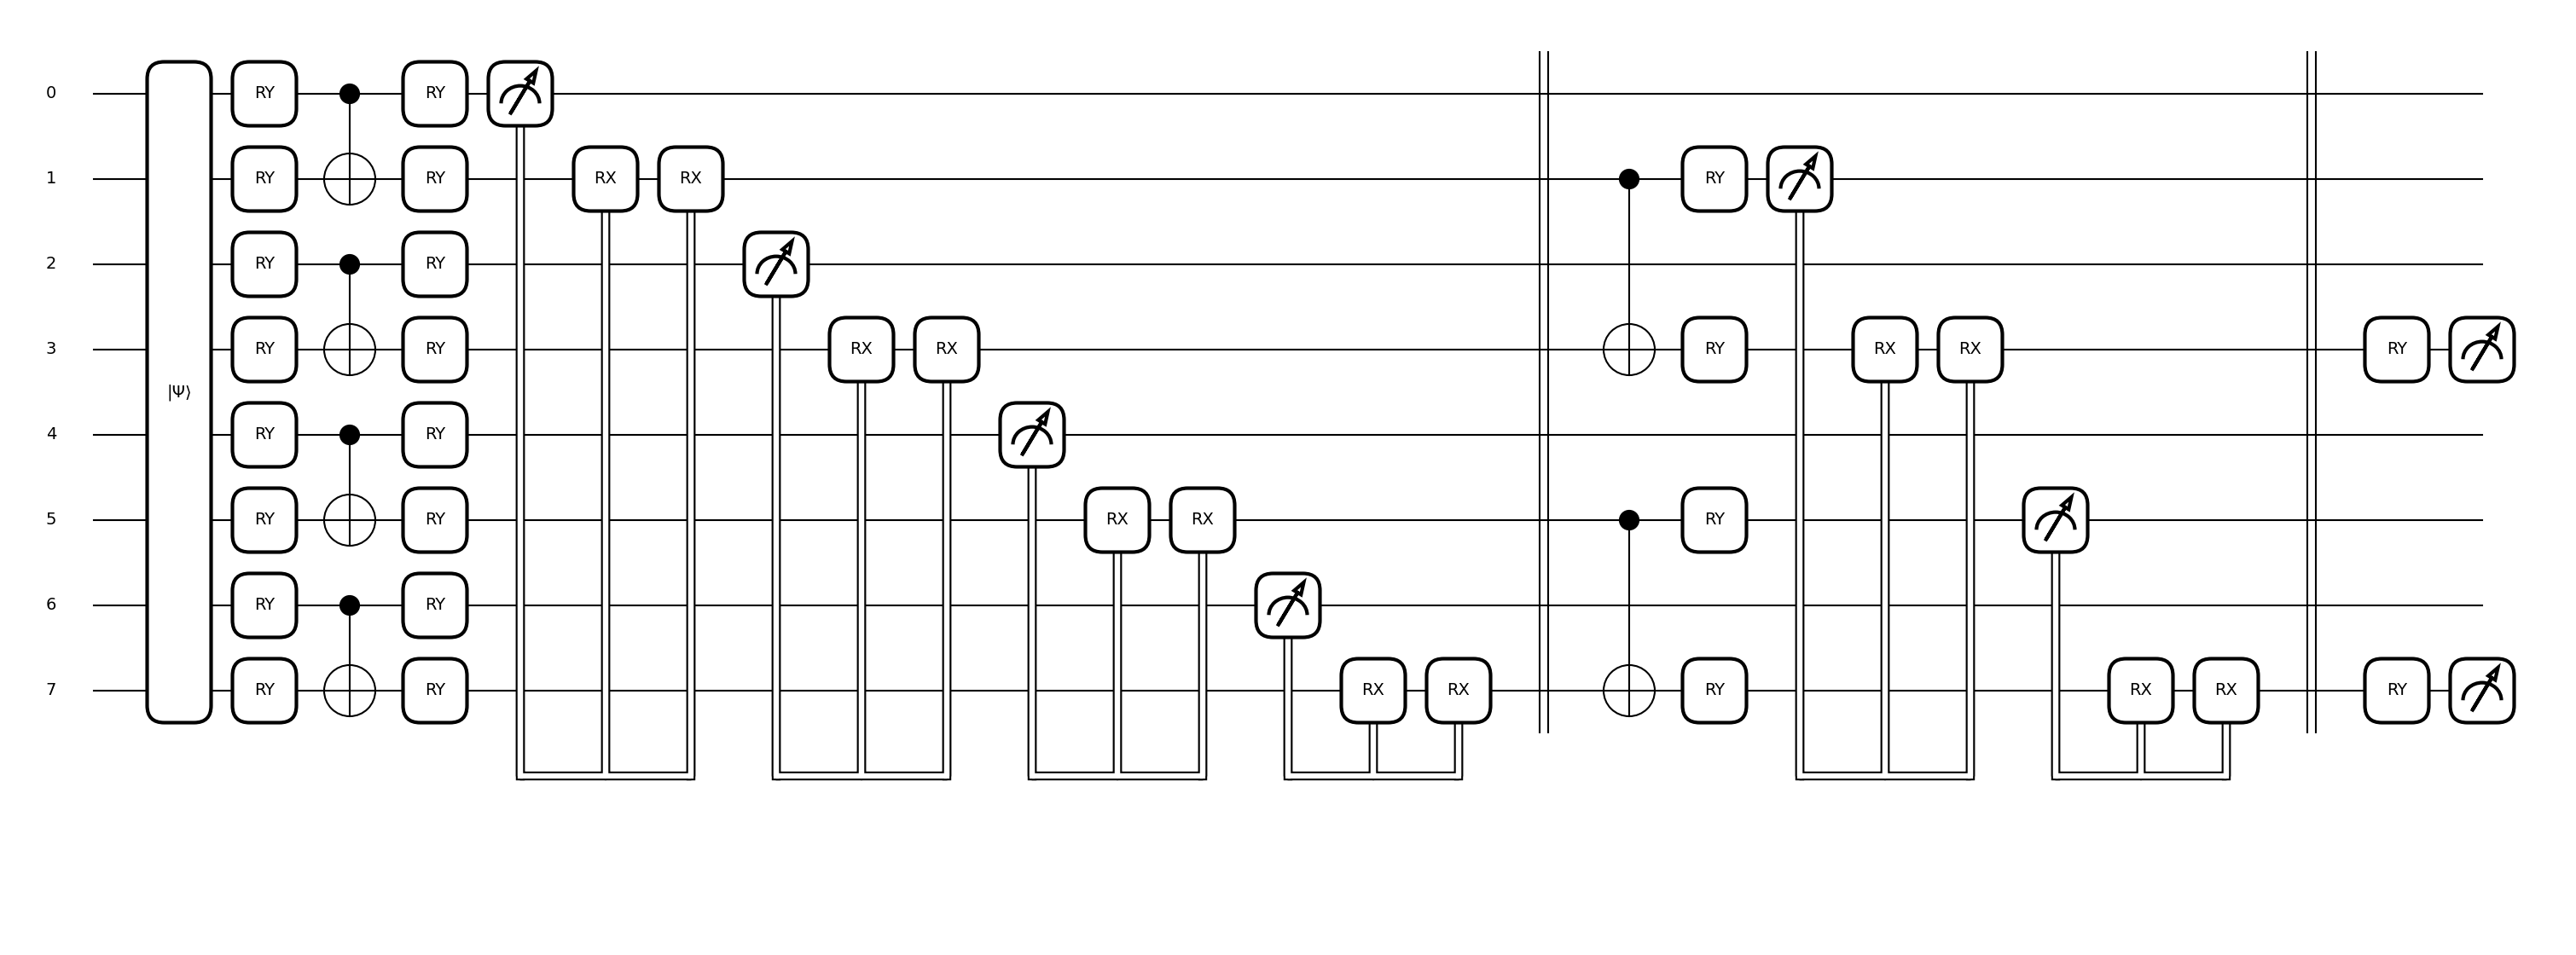

In [9]:
def qcnn_ansatz(num_qubits, params):
    """Ansatz of the QCNN model
    Repetitions of the convolutional and pooling blocks
    until only 2 wires are left unmeasured
    """

    # Convolution block
    def conv(wires, params, index):
        if len(wires) % 2 == 0:
            groups = wires.reshape(-1, 2)
        else:
            groups = wires[:-1].reshape(-1, 2)
            qml.RY(params[index], wires=int(wires[-1]))
            index += 1

        for group in groups:
            qml.CNOT(wires=[int(group[0]), int(group[1])])
            for wire in group:
                qml.RY(params[index], wires=int(wire))
                index += 1

        return index

    # Pooiling block
    def pool(wires, params, index):
        # Process wires in pairs: measure one and conditionally rotate the other.
        for wire_pool, wire in zip(wires[0::2], wires[1::2]):
            m_0 = qml.measure(int(wire_pool))
            qml.cond(m_0 == 0, qml.RX)(params[index],     wires=int(wire))
            qml.cond(m_0 == 1, qml.RX)(params[index + 1], wires=int(wire))
            index += 2
            # Remove the measured wire from active wires.
            wires = np.delete(wires, np.where(wires == wire_pool))

        # If an odd wire remains, apply a RX rotation.
        if len(wires) % 2 != 0:
            qml.RX(params[index], wires=int(wires[-1]))
            index += 1

        return index, wires

    # Initialize active wires and parameter index.
    active_wires = np.arange(num_qubits)
    index = 0

    # Initial layer: apply RY to all wires.
    for wire in active_wires:
        qml.RY(params[index], wires=int(wire))
        index += 1

    # Repeatedly apply convolution and pooling until there are 2 unmeasured wires
    while len(active_wires) > 2:
        # Convolution
        index = conv(active_wires, params, index)
        # Pooling
        index, active_wires = pool(active_wires, params, index)
        qml.Barrier()

    # Final layer: apply RY to the remaining active wires.
    for wire in active_wires:
        qml.RY(params[index], wires=int(wire))
        index += 1

    return index, active_wires

num_params, output_wires = qcnn_ansatz(num_qubits, [0]*100)

@qml.qnode(qml.device("default.qubit", wires=num_qubits))
def qcnn_circuit(params, state):
    """QNode with QCNN ansatz and probabilities of unmeasured qubits as output"""
    # Input ground state from diagonalization
    qml.StatePrep(state, wires=range(num_qubits), normalize = True)
    # QCNN
    _, output_wires = qcnn_ansatz(num_qubits, params)

    return qml.probs([int(k) for k in output_wires])

# Vectorized circuit through vmap
vectorized_qcnn_circuit = vmap(jit(qcnn_circuit), in_axes=(None, 0))

# Draw the QCNN Architecture
fig,ax = qml.draw_mpl(qcnn_circuit)(np.arange(num_params), psis[0,0])


In [10]:
def cross_entropy(pred, Y, T):
    """Multi-class cross entropy loss function"""
    epsilon = 1e-9  # Small value for numerical stability
    pred = jnp.clip(pred, epsilon, 1 - epsilon)  # Prevent log(0)

    # Apply sharpening (raise probabilities to the power of 1/T)
    pred_sharpened = pred ** (1 / T)
    pred_sharpened /= jnp.sum(pred_sharpened, axis=1, keepdims=True)  # Re-normalize

    loss = -jnp.sum(Y * jnp.log(pred_sharpened), axis=1)
    return jnp.mean(loss)


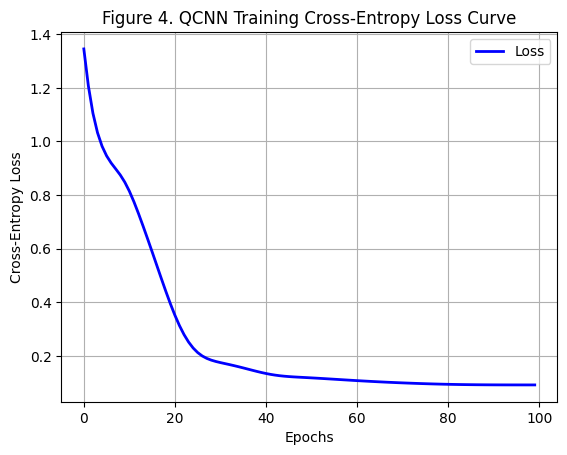

In [11]:
# Mask for the analytical points
analytical_mask = (K == 0) | (H == 0)


def train_qcnn(num_epochs, lr, T, seed):
    """Training function of the QCNN architecture"""

    # Initialize PRNG key
    key = random.PRNGKey(seed)
    key, subkey = random.split(key)

    # Define the loss function
    def loss_fun(params, X, Y):
        preds = vectorized_qcnn_circuit(params, X)
        return cross_entropy(preds, Y, T)

    # Consider only analytical points for the training
    X_train, Y_train = psis[analytical_mask], phases[analytical_mask]

    # Convert labels to one-hot encoding
    Y_train_onehot = jnp.eye(4)[Y_train]

    # Randomly initialize the parameters
    params = random.normal(subkey, (num_params,))

    # Initialize Adam optimizer
    optimizer = optax.adam(learning_rate=lr)
    optimizer_state = optimizer.init(params)

    loss_curve = []
    for epoch in range(num_epochs):
        # Compute loss and gradients
        loss, grads = value_and_grad(loss_fun)(params, X_train, Y_train_onehot)

        # Update parameters
        updates, optimizer_state = optimizer.update(grads, optimizer_state)
        params = optax.apply_updates(params, updates)

        loss_curve.append(loss)

    return params, loss_curve

train_qcnn = pantarei.Task(train_qcnn,clear_first=True)

trained_params, loss_curve = train_qcnn(num_epochs=100, lr=5e-2, T=.5, seed=seed)

# Plot the loss curve
plt.plot(loss_curve, label="Loss", color="blue", linewidth=2)
plt.xlabel("Epochs"), plt.ylabel("Cross-Entropy Loss")
plt.title("Figure 4. QCNN Training Cross-Entropy Loss Curve")
plt.legend()
plt.grid()
plt.show()


In [12]:
pantarei.report()

✅ ended   100% [1/1]
   ✅ train_qcnn/692b314ccaa8e45a04540bf93591e658 0:00:08 train_qcnn(num_epochs=100,lr=0.05,T=0.5,seed=123456)


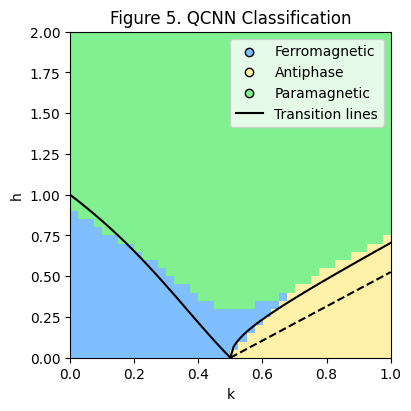

In [14]:
# Take the predicted classes for each point in the phase diagram
predicted_classes = np.argmax(
    vectorized_qcnn_circuit(trained_params, psis.reshape(-1, 2**num_qubits)),
    axis=1
)

colors = ['#80bfff', '#fff2a8',  '#80f090', '#da8080',]
phase_labels = ["Ferromagnetic", "Antiphase", "Paramagnetic", "Trash Class",]
cmap = ListedColormap(colors)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

# Plot the predictions over the phase diagram
plt.figure(figsize=(4,4), constrained_layout=True)
plt.imshow(
    predicted_classes.reshape(side, side),
    cmap=cmap,
    norm=norm,
    aspect="auto",
    origin="lower",
    extent=[0, 1, 0, 2]
)

# Plot the transition lines (Ising and KT) for reference.
k_vals1 = np.linspace(0.0, 0.5, 50)
k_vals2 = np.linspace(0.5, 1.0, 50)
plt.plot(k_vals1, ising_transition(k_vals1), 'k')
plt.plot(k_vals2, kt_transition(k_vals2), 'k')
plt.plot(k_vals2, bkt_transition(k_vals2), 'k', ls = '--')

for color, phase in zip(colors, phase_labels[:-1]):
    plt.scatter([], [], color=color, label=phase, edgecolors='black')
plt.plot([], [], 'k', label='Transition lines')

plt.xlabel("k"), plt.ylabel("h")
plt.title("Figure 5. QCNN Classification")
plt.legend()
plt.show()


## Time Evolution

In [15]:
def evolve_and_classify(initial_state=None, k=None, h=None, num_time_steps=50, deltaT=0.05, random_seed=None):
    if random_seed:
        np.random.seed(random_seed)
        
    if k is None:
        k = np.random.uniform(0, 1)
    if h is None:
        h = np.random.uniform(0, 2)

    if initial_state is None:# Get initial ground state
        H_matrix = np.real(qml.matrix(get_H(num_qubits, k, h)))
        _, psi0 = jnp.linalg.eigh(H_matrix)
        initial_state = jnp.array(psi0[:, 0], dtype=jnp.complex64)

        
    # Set up time evolution
    H_hamiltonian = get_H(num_qubits, k, h)

    @qml.qnode(qml.device("default.qubit", wires=num_qubits))
    def time_evolution(t):
        qml.StatePrep(initial_state, wires=range(num_qubits), normalize=True)
        qml.TrotterProduct(H_hamiltonian, time=t, order=2, n=10)
        return qml.state()
    
    # Track overlap and classification
    times = np.arange(0, num_time_steps * deltaT, deltaT)
    overlaps = []
    classifications = []


    pbar= tqdm.tqdm(total=num_time_steps,desc="Time progress")
    for t in times:
        pbar.update(1)
        evolved_state = time_evolution(t)
        overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
        overlaps.append(overlap)
        
        # Classify
        probs = vectorized_qcnn_circuit(trained_params, evolved_state.reshape(1, -1))
        classifications.append(np.argmax(probs))
    pbar.close()
    return times, overlaps, classifications



Let's take a look what happens on the phase transition lines

Time progress: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:04<00:00,  1.29s/it]


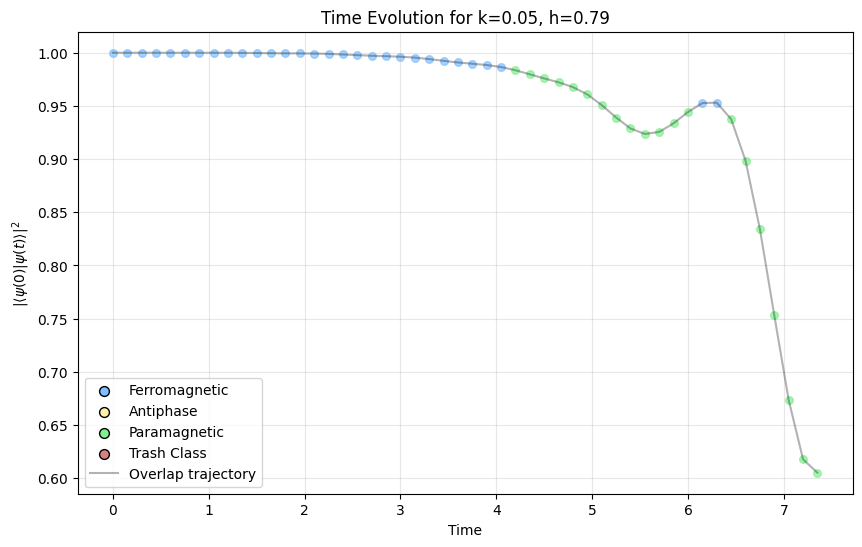

In [28]:
# Choose a point on the ising phase transition line
k_transition = 0.1
h_transition = ising_transition(k_transition)  
# Choose a point on the ising phase transition line
k_transition = 0.1
h_transition = ising_transition(k_transition)  

delta_phase = -0.05
k_transition += delta_phase
h_transition += delta_phase

# Get the ground state
H_matrix = np.real(qml.matrix(get_H(num_qubits, k_transition, h_transition)))
_, psi0 = jnp.linalg.eigh(H_matrix)
initial_state = jnp.array(psi0[:, 0], dtype=jnp.complex64)


# Run the evolution
times, overlaps, classifications = evolve_and_classify(initial_state=initial_state, k=k_transition, h=h_transition,deltaT=0.15)
# times, overlaps, classifications = evolve_and_classify(initial_state=initial_state, k=k_transition, h=h_transition)
k = k_transition
h = h_transition

# Plot with color-coded points
colors = ['#80bfff', '#fff2a8', '#80f090', '#da8080']
phase_names = ["Ferromagnetic", "Antiphase", "Paramagnetic", "Trash Class"]

plt.figure(figsize=(10, 6))
for i, (t, overlap, cls) in enumerate(zip(times, overlaps, classifications)):
    plt.scatter(t, overlap, color=colors[cls], s=30, alpha=0.7)

# Add phase labels to legend
for color, name in zip(colors, phase_names):
    plt.scatter([], [], color=color, label=name, s=50, edgecolors='black')

plt.plot(times, overlaps, 'k-', alpha=0.3, label='Overlap trajectory')
plt.xlabel("Time")
plt.ylabel(r"$|\langle\psi(0)|\psi(t)\rangle|^2$")
plt.title(f"Time Evolution for k={k:.2f}, h={h:.2f}")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()


delta_phase = -0.05
k_transition += delta_phase
h_transition += delta_phase

# Get the ground state
H_matrix = np.real(qml.matrix(get_H(num_qubits, k_transition, h_transition)))
_, psi0 = jnp.linalg.eigh(H_matrix)
initial_state = jnp.array(psi0[:, 0], dtype=jnp.complex64)


# Run the evolution
times, overlaps, classifications = evolve_and_classify(initial_state=initial_state, k=k_transition, h=h_transition,deltaT=0.15)
# times, overlaps, classifications = evolve_and_classify(initial_state=initial_state, k=k_transition, h=h_transition)
k = k_transition
h = h_transition

# Plot with color-coded points
colors = ['#80bfff', '#fff2a8', '#80f090', '#da8080']
phase_names = ["Ferromagnetic", "Antiphase", "Paramagnetic", "Trash Class"]

plt.figure(figsize=(10, 6))
for i, (t, overlap, cls) in enumerate(zip(times, overlaps, classifications)):
    plt.scatter(t, overlap, color=colors[cls], s=30, alpha=0.7)

# Add phase labels to legend
for color, name in zip(colors, phase_names):
    plt.scatter([], [], color=color, label=name, s=50, edgecolors='black')

plt.plot(times, overlaps, 'k-', alpha=0.3, label='Overlap trajectory')
plt.xlabel("Time")
plt.ylabel(r"$|\langle\psi(0)|\psi(t)\rangle|^2$")
plt.title(f"Time Evolution for k={k:.2f}, h={h:.2f}")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()



Time progress: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:23<00:00,  2.14it/s]


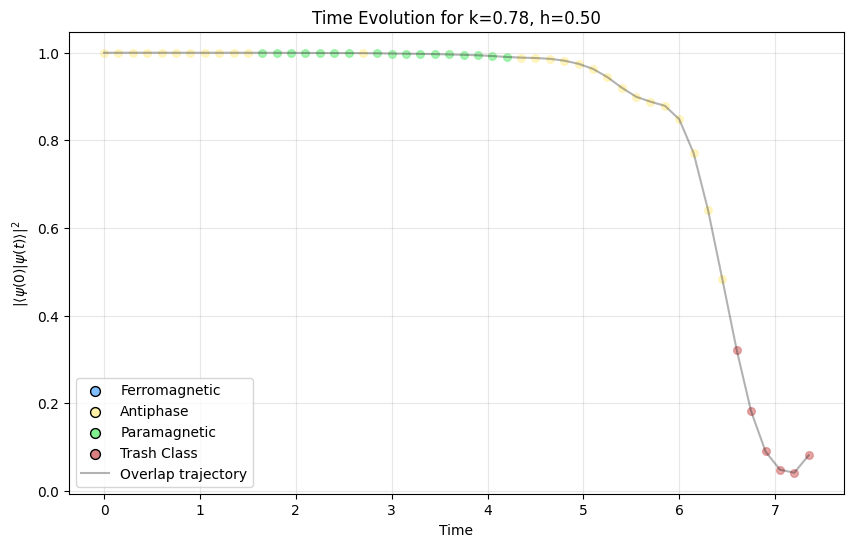

In [22]:
# Choose a point on the kt phase transition line
# k_transition = np.random.uniform(0.5, 1.0)  
k_transition = 0.8
h_transition = kt_transition(k_transition)  

# k_transition = 0.1
# h_transition = ising_transition(k_transition)  

delta_phase = 0.021
k_transition -= delta_phase
h_transition += delta_phase

# Get the ground state
H_matrix = np.real(qml.matrix(get_H(num_qubits, k_transition, h_transition)))
_, psi0 = jnp.linalg.eigh(H_matrix)
initial_state = jnp.array(psi0[:, 0], dtype=jnp.complex64)


# Run the evolution
times, overlaps, classifications = evolve_and_classify(initial_state=initial_state, k=k_transition, h=h_transition,deltaT=0.15)
# times, overlaps, classifications = evolve_and_classify(initial_state=initial_state, k=k_transition, h=h_transition,deltaT=0.3,num_time_steps=25)
k = k_transition
h = h_transition

# Plot with color-coded points
colors = ['#80bfff', '#fff2a8', '#80f090', '#da8080']
phase_names = ["Ferromagnetic", "Antiphase", "Paramagnetic", "Trash Class"]

plt.figure(figsize=(10, 6))
for i, (t, overlap, cls) in enumerate(zip(times, overlaps, classifications)):
    plt.scatter(t, overlap, color=colors[cls], s=30, alpha=0.7)

# Add phase labels to legend
for color, name in zip(colors, phase_names):
    plt.scatter([], [], color=color, label=name, s=50, edgecolors='black')

plt.plot(times, overlaps, 'k-', alpha=0.3, label='Overlap trajectory')
plt.xlabel("Time")
plt.ylabel(r"$|\langle\psi(0)|\psi(t)\rangle|^2$")
plt.title(f"Time Evolution for k={k:.2f}, h={h:.2f}")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()



Let's see what happens when the initial state is in a supperposition between the ground state in the paramagnetic phase and the ground state in the antiphase

Time progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:07<00:00,  1.49it/s]


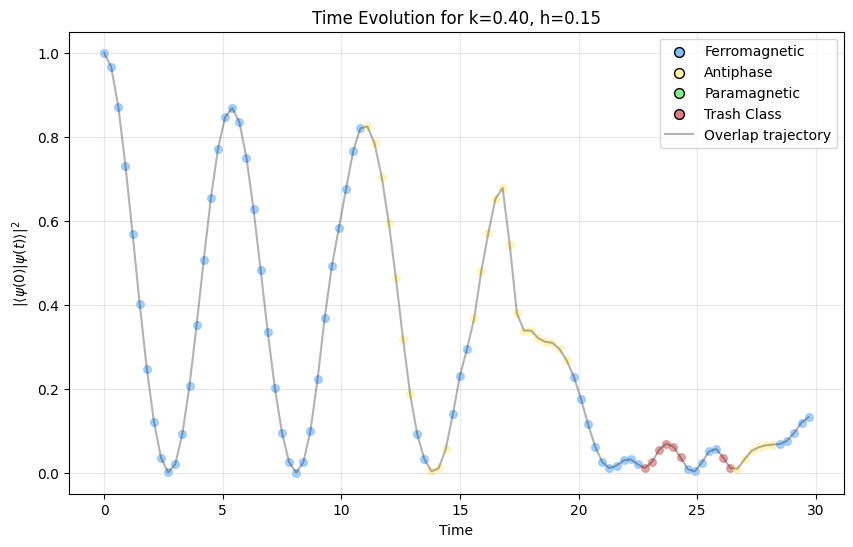

In [22]:
# Define two points with different phases
k1, h1 = 0.8, 0.3   # paramagnetic 
k2, h2 = 0.6, 0.65  # antiphase 
k2, h2 = 0., 0.     # ferromagnetic 

k_evol = (k1+k2)/2
h_evol = (h1+h2)/2

# Get the ground states
H1 = np.real(qml.matrix(get_H(num_qubits, k1, h1)))
_, psi1 = jnp.linalg.eigh(H1)
psi1 = jnp.array(psi1[:, 0], dtype=jnp.complex64)

H2 = np.real(qml.matrix(get_H(num_qubits, k2, h2)))
_, psi2 = jnp.linalg.eigh(H2)
psi2 = jnp.array(psi2[:, 0], dtype=jnp.complex64)

# Create superposition (equal weights)
initial_state = (psi1 + psi2) / jnp.sqrt(2)


# Run the evolution
# times, overlaps, classifications = evolve_and_classify(initial_state=initial_state, k=k_evol, h=h_evol)
times, overlaps, classifications = evolve_and_classify(initial_state=initial_state, k=k_evol, h=h_evol, deltaT=0.3,num_time_steps=100)
k = k_evol
h = h_evol


# Plot with color-coded points
colors = ['#80bfff', '#fff2a8', '#80f090', '#da8080']
phase_names = ["Ferromagnetic", "Antiphase", "Paramagnetic", "Trash Class"]

plt.figure(figsize=(10, 6))
for i, (t, overlap, cls) in enumerate(zip(times, overlaps, classifications)):
    plt.scatter(t, overlap, color=colors[cls], s=30, alpha=0.7)

# Add phase labels to legend
for color, name in zip(colors, phase_names):
    plt.scatter([], [], color=color, label=name, s=50, edgecolors='black')

plt.plot(times, overlaps, 'k-', alpha=0.3, label='Overlap trajectory')
plt.xlabel("Time")
plt.ylabel(r"$|\langle\psi(0)|\psi(t)\rangle|^2$")
plt.title(f"Time Evolution for k={k:.2f}, h={h:.2f}")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()



## Unsupervised Learning

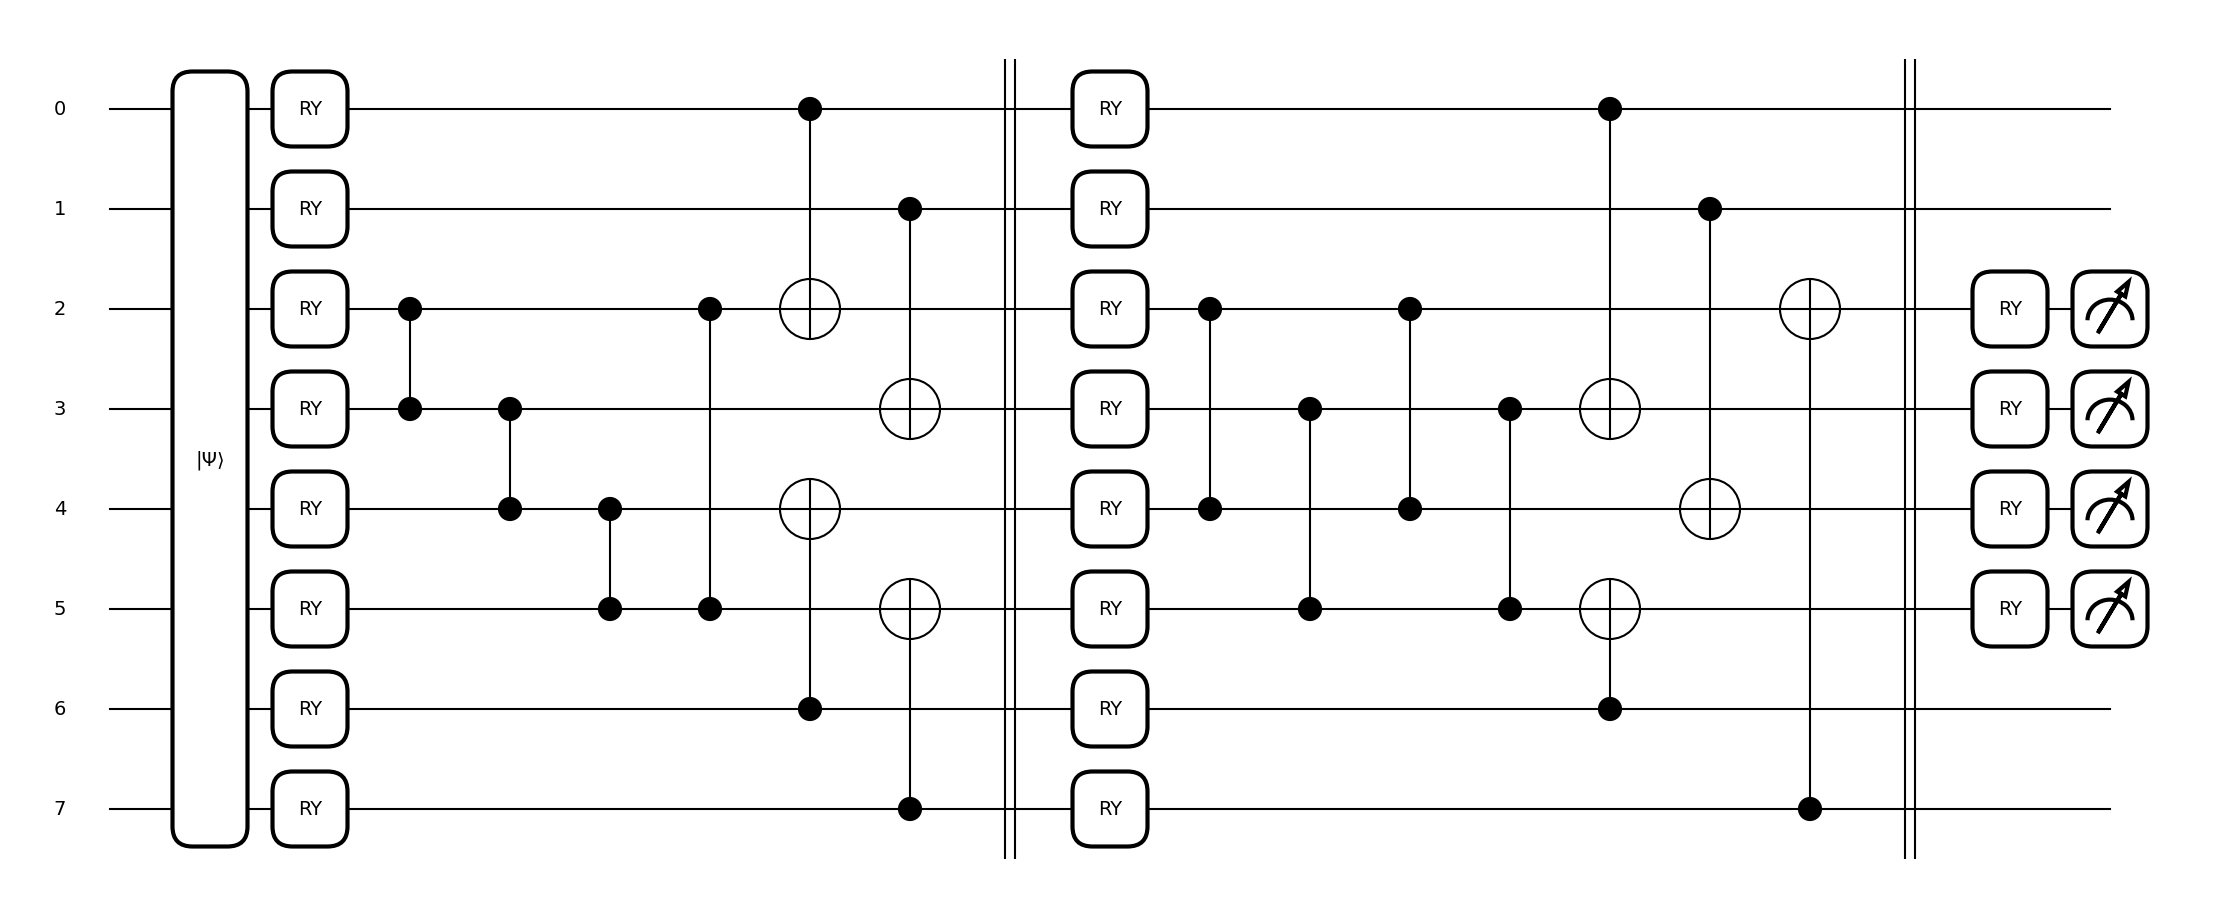

In [23]:
def anomaly_ansatz(n_qubit, params):
    """Ansatz of the QAD model
    Apply multi-qubit gates between trash and non-trash wires
    """

    # Block of gates connecting trash and non-trash wires
    def block(nontrash, trash, shift):
        # Connect trash wires
        for i, wire in enumerate(trash):
            target = trash[(i + 1 + shift) % len(trash)]
            qml.CZ(wires=[int(wire), int(target)])
        # Connect each nontrash wire to a trash wire
        for i, wire in enumerate(nontrash):
            trash_idx = (i + shift) % len(trash)
            qml.CNOT(wires=[int(wire), int(trash[trash_idx])])

    depth = 2  # Number of repeated block layers
    n_trashwire = n_qubit // 2

    # Define trash wires as a contiguous block in the middle.
    trash = np.arange(n_trashwire // 2, n_trashwire // 2 + n_trashwire)
    nontrash = np.setdiff1d(np.arange(n_qubit), trash)

    index = 0

    # Initial layer: apply RY rotations on all wires.
    for wire in np.arange(n_qubit):
        qml.RY(params[index], wires=int(wire))
        index += 1

    # Repeatedly apply blocks of entangling gates and additional rotations.
    for shift in range(depth):
        block(nontrash, trash, shift)
        qml.Barrier()
        # In the final layer, only apply rotations on trash wires.
        wires_to_rot = np.arange(n_qubit) if shift < depth - 1 else trash
        for wire in wires_to_rot:
            qml.RY(params[index], wires=int(wire))
            index += 1

    return index, list(trash)

num_anomaly_params, trash_wires = qcnn_ansatz(num_qubits, [0]*100)

@qml.qnode(qml.device("default.qubit", wires=num_qubits))
def anomaly_circuit(params, state):
    """QNode with QAD ansatz and expectation values of the trash wires as output"""
    # Input ground state from diagonalization
    qml.StatePrep(state, wires=range(num_qubits), normalize = True)
    # Quantum Anomaly Circuit
    _, trash_wires = anomaly_ansatz(num_qubits, params)

    return [qml.expval(qml.PauliZ(int(k))) for k in trash_wires]

# Vectorize the circuit using vmap
jitted_anomaly_circuit = jit(anomaly_circuit)
vectorized_anomaly_circuit = vmap(jitted_anomaly_circuit, in_axes=(None, 0))

# Draw the QAD Architecture
fig,ax = qml.draw_mpl(anomaly_circuit)(np.arange(num_anomaly_params), psis[0,0])


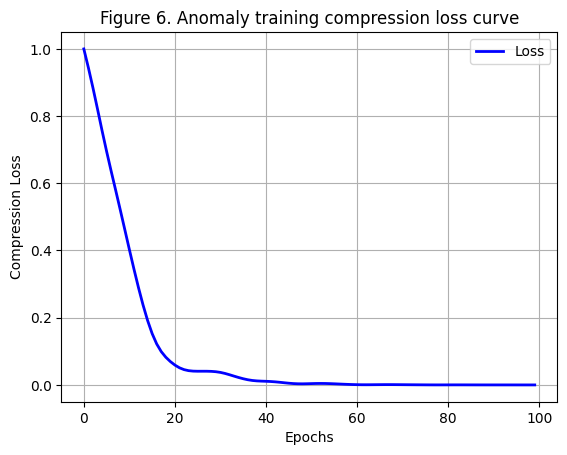

In [24]:
def train_anomaly(num_epochs, lr, seed):
    """Training function of the QAD architecture"""

    # Initialize PRNG key
    key = random.PRNGKey(seed)
    key, subkey = random.split(key)

    # Define the loss function
    def loss_fun(params, X):
        # Output expectation values of the qubits
        score = 1 - jnp.array(jitted_anomaly_circuit(params, X))
        loss_value = jnp.mean(score)

        return loss_value

    # Training set consists only of the k = 0 and h = 0 state
    X_train = jnp.array(psis[0, 0])

    # Randomly initialize parameters
    params = random.normal(subkey, (num_anomaly_params,))

    optimizer = optax.adam(learning_rate=lr)
    optimizer_state = optimizer.init(params)

    loss_curve = []
    for epoch in range(num_epochs):
        # Get random indices for a batch
        key, subkey = random.split(key)

        # Compute loss and gradients
        loss, grads = value_and_grad(loss_fun)(params, X_train)

        # Update parameters
        updates, optimizer_state = optimizer.update(grads, optimizer_state)
        params = optax.apply_updates(params, updates)

        loss_curve.append(loss)

    return params, loss_curve

trained_anomaly_params, anomaly_loss_curve = train_anomaly(num_epochs=100, lr=1e-1, seed=seed)

# Plot the loss curve

plt.plot(anomaly_loss_curve, label="Loss", color="blue", linewidth=2)
plt.xlabel("Epochs"), plt.ylabel("Compression Loss")
plt.title("Figure 6. Anomaly training compression loss curve")
plt.legend()
plt.grid()
plt.show()


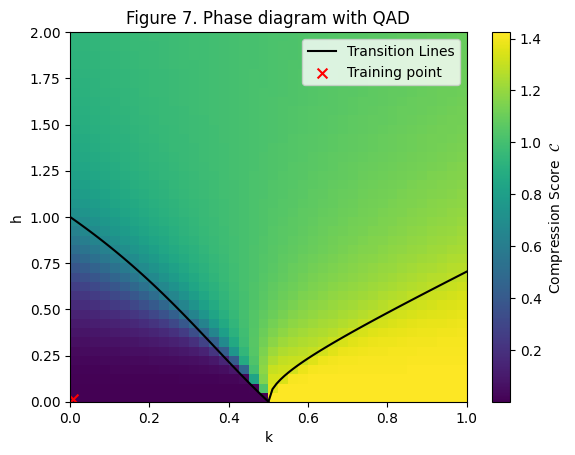

In [25]:
# Evaluate the compression score for each state in the phase diagram
compressions = vectorized_anomaly_circuit(trained_anomaly_params, psis.reshape(-1, 2**num_qubits))
compressions = jnp.mean(1 - jnp.array(compressions), axis = 0)

im = plt.imshow(compressions.reshape(side, side), aspect="auto", origin="lower", extent=[0, 1, 0, 2])

# Plot transition lines (assuming ising_transition and kt_transition are defined)
plt.plot(np.linspace(0.0, 0.5, 50), ising_transition(np.linspace(0.0, 0.5, 50)), 'k')
plt.plot(np.linspace(0.5, 1.0, 50), kt_transition(np.linspace(0.5, 1.0, 50)), 'k')

plt.plot([], [], 'k', label='Transition Lines')
plt.scatter([0 +.3/len(ks)], [0 + .5/len(hs)], color='r', marker = 'x', label="Training point", s=50)

plt.legend(), plt.xlabel("k"), plt.ylabel("h"), plt.title("Figure 7. Phase diagram with QAD")
cbar = plt.colorbar(im)
cbar.set_label(r"Compression Score  $\mathcal{C}$")
plt.show()


In [28]:
def evolve_and_classify_QAD(initial_state=None, k=None, h=None, num_time_steps=50, deltaT=0.05, random_seed=None):
    if random_seed:
        np.random.seed(random_seed)
        
    if k is None:
        k = np.random.uniform(0, 1)
    if h is None:
        h = np.random.uniform(0, 2)

    if initial_state is None:# Get initial ground state
        H_matrix = np.real(qml.matrix(get_H(num_qubits, k, h)))
        _, psi0 = jnp.linalg.eigh(H_matrix)
        initial_state = jnp.array(psi0[:, 0], dtype=jnp.complex64)

        
    # Set up time evolution
    H_hamiltonian = get_H(num_qubits, k, h)

    @qml.qnode(qml.device("default.qubit", wires=num_qubits))
    def time_evolution(t):
        qml.StatePrep(initial_state, wires=range(num_qubits), normalize=True)
        qml.TrotterProduct(H_hamiltonian, time=t, order=2, n=10)
        return qml.state()
    
    # Track overlap and classification
    times = np.arange(0, num_time_steps * deltaT, deltaT)
    overlaps = []
    compression_scores = []


    pbar= tqdm.tqdm(total=num_time_steps,desc="Time progress")
    for t in times:
        pbar.update(1)
        evolved_state = time_evolution(t)
        overlap = np.abs(np.dot(np.conj(initial_state), evolved_state))**2
        overlaps.append(overlap)
        
        # Evaluate the compression score 
        comp = vectorized_anomaly_circuit(trained_anomaly_params, evolved_state.reshape(1, -1))
        compression_scores.append(jnp.mean(1 - jnp.array(comp), axis=0)[0])


        
        # probs = vectorized_qcnn_circuit(trained_params, evolved_state.reshape(1, -1))
        # classifications.append(np.argmax(probs))
    pbar.close()
    return times, overlaps, compression_scores



Time progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:45<00:00,  2.20it/s]


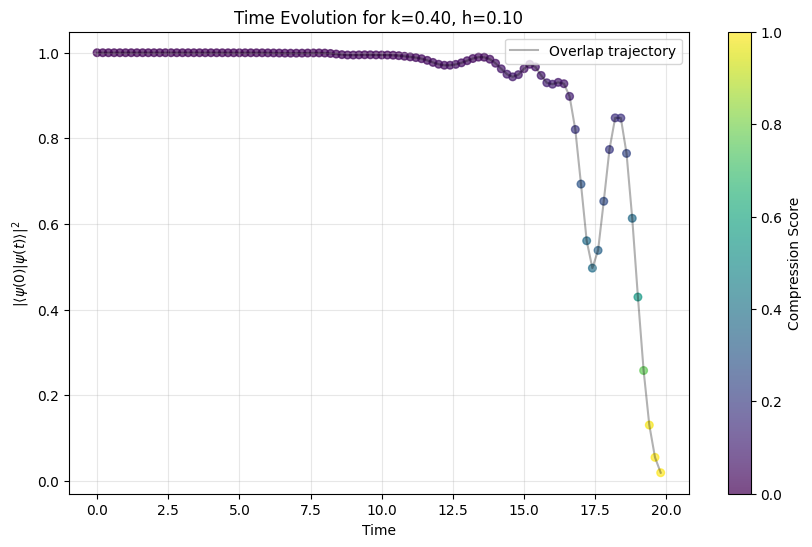

In [70]:
# Choose a point on the ising phase transition line
k_transition = 0.1
k_transition = 0.5
h_transition = ising_transition(k_transition)  

# delta_phase = -0.01
# k_transition += delta_phase
# h_transition -= delta_phase

k_transition += -0.1
h_transition += 0.1

# Get the ground state
H_matrix = np.real(qml.matrix(get_H(num_qubits, k_transition, h_transition)))
_, psi0 = jnp.linalg.eigh(H_matrix)
initial_state = jnp.array(psi0[:, 0], dtype=jnp.complex64)


# Run the evolution
# times, overlaps, compression_scores = evolve_and_classify_QAD(initial_state=initial_state, k=k_transition, h=h_transition,deltaT=0.15)
times, overlaps, compression_scores = evolve_and_classify_QAD(
    initial_state=initial_state, k=k_transition, h=h_transition,deltaT=0.2,num_time_steps=100)
# times, overlaps, compression_scores = evolve_and_classify(initial_state=initial_state, k=k_transition, h=h_transition)
k = k_transition
h = h_transition


plt.figure(figsize=(10, 6))
sc = plt.scatter(times, overlaps, c=compression_scores, cmap='viridis', 
                 s=30, alpha=0.7, vmin=0, vmax=1)

cbar = plt.colorbar(sc)
cbar.set_label("Compression Score")

plt.plot(times, overlaps, 'k-', alpha=0.3, label='Overlap trajectory')
plt.xlabel("Time")
plt.ylabel(r"$|\langle\psi(0)|\psi(t)\rangle|^2$")
plt.title(f"Time Evolution for k={k:.2f}, h={h:.2f}")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()







Time progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:49<00:00,  2.01it/s]


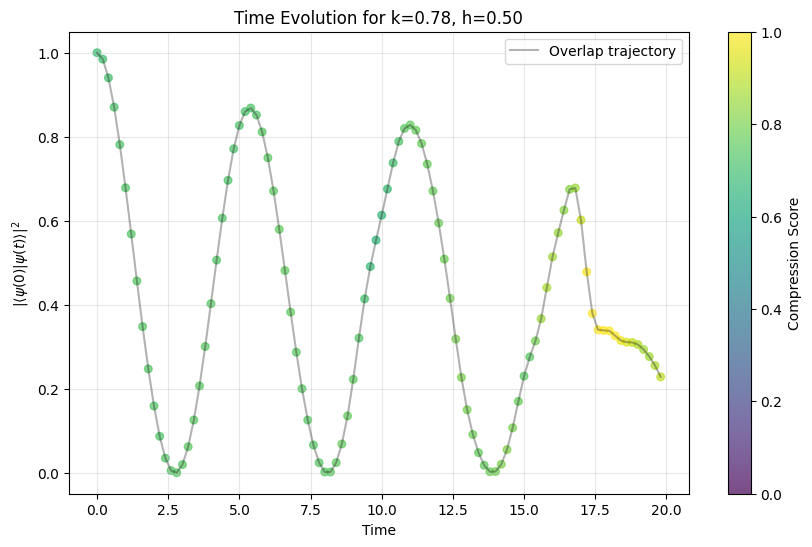

In [73]:
# Define two points with different phases
k1, h1 = 0.8, 0.3   # paramagnetic 
k2, h2 = 0.6, 0.65  # antiphase 
k2, h2 = 0., 0.     # ferromagnetic 

k_evol = (k1+k2)/2
h_evol = (h1+h2)/2

# Get the ground states
H1 = np.real(qml.matrix(get_H(num_qubits, k1, h1)))
_, psi1 = jnp.linalg.eigh(H1)
psi1 = jnp.array(psi1[:, 0], dtype=jnp.complex64)

H2 = np.real(qml.matrix(get_H(num_qubits, k2, h2)))
_, psi2 = jnp.linalg.eigh(H2)
psi2 = jnp.array(psi2[:, 0], dtype=jnp.complex64)

# Create superposition (equal weights)
initial_state = (psi1 + psi2) / jnp.sqrt(2)


# Run the evolution
# times, overlaps, compression_scores = evolve_and_classify_QAD(initial_state=initial_state, k=k_transition, h=h_transition,deltaT=0.15)
times, overlaps, compression_scores = evolve_and_classify_QAD(
    initial_state=initial_state, k=k_evol, h=h_evol,deltaT=0.2,num_time_steps=100)
# times, overlaps, compression_scores = evolve_and_classify(initial_state=initial_state, k=k_transition, h=h_transition)
k = k_transition
h = h_transition


plt.figure(figsize=(10, 6))
sc = plt.scatter(times, overlaps, c=compression_scores, cmap='viridis', 
                 s=30, alpha=0.7, vmin=0, vmax=1)

cbar = plt.colorbar(sc)
cbar.set_label("Compression Score")

plt.plot(times, overlaps, 'k-', alpha=0.3, label='Overlap trajectory')
plt.xlabel("Time")
plt.ylabel(r"$|\langle\psi(0)|\psi(t)\rangle|^2$")
plt.title(f"Time Evolution for k={k:.2f}, h={h:.2f}")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()